# Before You Start

This notebook now builds a molecular activity classification dataset from the local ChEMBL 36 SQLite archive in this folder. A GPU is optional for data preparation, but recommended for the MolFormer/ChemBERTa training cells.


# Preparation

In [23]:
# @title Install the packages needed for this work
# @markdown This installs the packages used for ChEMBL data handling, scaffold-aware splitting,
# @markdown molecular fingerprints, plotting, and transformer fine-tuning.
# %%capture

!pip install -q pandas hestia-good seaborn rdkit scikit-learn scipy
!pip install -q transformers accelerate datasets tensorboard


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [24]:
# @title Load ChEMBL 36 activity data
# @markdown The schema documents in this folder show the ChEMBL join path used here:
# @markdown `activities` -> `assays` -> `target_dictionary` for target-specific pChEMBL values, and
# @markdown `activities` -> `molecule_dictionary` -> `compound_structures` for compound IDs and SMILES.
# @markdown
# @markdown By default this cell builds an EGFR activity dataset. Change `target_chembl_id`,
# @markdown `activity_types`, or `active_threshold` to build a dataset for a different target or endpoint.

from pathlib import Path
import sqlite3
import tarfile

import pandas as pd

archive_path = Path('chembl_36_sqlite.tar.gz')
db_path = Path('chembl_36/chembl_36_sqlite/chembl_36.db')

def safe_extract_tar(archive: Path, destination: Path = Path('.')) -> None:
    destination = destination.resolve()
    with tarfile.open(archive, 'r:gz') as tar:
        for member in tar.getmembers():
            member_path = (destination / member.name).resolve()
            if destination != member_path and destination not in member_path.parents:
                raise RuntimeError(f'Unsafe path in archive: {member.name}')
        tar.extractall(destination)

if not db_path.exists():
    if not archive_path.exists():
        raise FileNotFoundError(
            'Expected chembl_36_sqlite.tar.gz or chembl_36/chembl_36_sqlite/chembl_36.db '
            'in the notebook folder.'
        )
    print('Extracting ChEMBL 36 SQLite database. This can take several minutes.')
    safe_extract_tar(archive_path)

# Human epidermal growth factor receptor erbB1 / EGFR in ChEMBL.
target_chembl_id = 'CHEMBL203'
activity_types = ('IC50', 'Ki', 'Kd', 'EC50')
active_threshold = 6.0  # pChEMBL >= 6 means activity at 1 uM or better.
placeholders = ', '.join('?' for _ in activity_types)
query = f'''
SELECT
    cs.canonical_smiles AS Drug,
    md.chembl_id AS molecule_chembl_id,
    md.pref_name AS molecule_name,
    td.chembl_id AS target_chembl_id,
    td.pref_name AS target_name,
    AVG(a.pchembl_value) AS pchembl_value,
    COUNT(*) AS measurements
FROM activities a
JOIN assays ass ON a.assay_id = ass.assay_id
JOIN target_dictionary td ON ass.tid = td.tid
JOIN molecule_dictionary md ON a.molregno = md.molregno
JOIN compound_structures cs ON md.molregno = cs.molregno
WHERE td.chembl_id = ?
  AND ass.confidence_score >= 8
  AND a.pchembl_value IS NOT NULL
  AND a.standard_type IN ({placeholders})
  AND cs.canonical_smiles IS NOT NULL
  AND md.structure_type = 'MOL'
  AND (a.data_validity_comment IS NULL OR a.data_validity_comment = 'Manually validated')
  AND COALESCE(a.potential_duplicate, 0) = 0
GROUP BY cs.canonical_smiles, md.chembl_id, md.pref_name, td.chembl_id, td.pref_name
'''

with sqlite3.connect(db_path) as con:
    raw_df = pd.read_sql_query(query, con, params=(target_chembl_id, *activity_types))

if raw_df.empty:
    raise ValueError(
        f'No ChEMBL 36 activity rows found for target_chembl_id={target_chembl_id!r}. '
        'Try another target from target_dictionary or relax the filters.'
    )

df = raw_df.dropna(subset=['Drug', 'pchembl_value']).copy()
df['Y'] = (df['pchembl_value'] >= active_threshold).astype(int)

if df['Y'].nunique() < 2:
    raise ValueError(
        f'The selected target produced only one class at pChEMBL threshold {active_threshold}. '
        'Adjust active_threshold or choose a different target.'
    )

print(f'Loaded {len(raw_df):,} unique ChEMBL compounds for {df["target_name"].iloc[0]} ({target_chembl_id}).')
print(f'Using {len(df):,} examples after thresholding at pChEMBL >= {active_threshold}.')
print(df['Y'].value_counts().rename(index={0: 'inactive', 1: 'active'}))
df.head()


Loaded 10,862 unique ChEMBL compounds for Epidermal growth factor receptor (CHEMBL203).
Using 10,862 examples after thresholding at pChEMBL >= 6.0.
Y
active      8099
inactive    2763
Name: count, dtype: int64


,Drug,molecule_chembl_id,molecule_name,target_chembl_id,target_name,pchembl_value,measurements,Y
0,Br.CC(Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1ccc(C(...,CHEMBL1914657,None,CHEMBL203,Epidermal growth factor receptor,5.34,1,0
1,Br.CC(Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1cccc2c...,CHEMBL1914666,None,CHEMBL203,Epidermal growth factor receptor,6.00,1,1
2,Br.CC[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1...,CHEMBL1914665,None,CHEMBL203,Epidermal growth factor receptor,8.40,1,1
3,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1c...,CHEMBL1914655,None,CHEMBL203,Epidermal growth factor receptor,7.21,1,1
4,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1c...,CHEMBL1914654,None,CHEMBL203,Epidermal growth factor receptor,8.42,1,1


# Data Analysis

In [25]:
# @title 1. What do the data look like?
# @markdown Before training anything, it is important to understand what kind of data we are working with. We will start by looking at a table with the data.
df.head()

,Drug,molecule_chembl_id,molecule_name,target_chembl_id,target_name,pchembl_value,measurements,Y
0,Br.CC(Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1ccc(C(...,CHEMBL1914657,None,CHEMBL203,Epidermal growth factor receptor,5.34,1,0
1,Br.CC(Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1cccc2c...,CHEMBL1914666,None,CHEMBL203,Epidermal growth factor receptor,6.00,1,1
2,Br.CC[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1...,CHEMBL1914665,None,CHEMBL203,Epidermal growth factor receptor,8.40,1,1
3,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1c...,CHEMBL1914655,None,CHEMBL203,Epidermal growth factor receptor,7.21,1,1
4,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1c...,CHEMBL1914654,None,CHEMBL203,Epidermal growth factor receptor,8.42,1,1


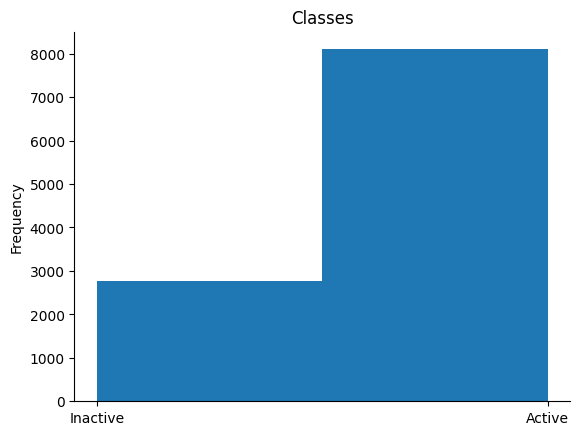

In [26]:
# @title 2. Visualizing the classes
# @markdown We balance the active and inactive classes in the ChEMBL loading cell, so this should show roughly equal counts.

from matplotlib import pyplot as plt
df['Y'].plot(kind='hist', bins=2, title='Classes')
plt.xticks([0, 1], ['Inactive', 'Active'])
plt.gca().spines[['top', 'right',]].set_visible(False)


In [27]:
# @title 3. Splitting the data into training, validation, and test sets
# @markdown We use Hestia to split the ChEMBL compounds by molecular similarity. Similarity is computed
# @markdown from ECFP molecular fingerprints with radius 2 and 2,048 bits.
# @markdown - Fingerprint:
# @markdown     - ECFP
# @markdown     - MAPc
# @markdown - Radius:
# @markdown    - 2 to 6
# @markdown - Number of bits:
# @markdown    - 256 to 2048
# @markdown - Threshold:
# @markdown    - 0.1 to 0.9

from hestia.partition import ccpart, random_partition
from hestia.similarity import molecular_similarity

sim_df = molecular_similarity(
    df_query=df,
    fingerprint='ecfp', # or mapc
    radius=2, # Try other radii, using integers
    bits=2048, # Try 256 to 2048, using multiples of 2
    df=df,
    field_name='Drug',
    verbose=3
)

train, test, clusters = ccpart(
    df=df,
    sim_df=sim_df,
    test_size=0.2,
    threshold=0.4, # Try other thresholds, 0.1 - 0.9
)
train_df, test_df = df.iloc[train, :].copy().reset_index(), df.iloc[test, :].copy().reset_index()
train, val = random_partition(
    train_df, test_size=0.1, random_state=42
)
train_df, val_df = df.iloc[train, :].copy().reset_index(), df.iloc[val, :].copy().reset_index()

print(f'Training set size: {len(train_df):,}')
print(f'Validation set size: {len(val_df):,}')
print(f'Test set size: {len(test_df):,}')


Calculating molecular similarities using ecfp with 2,048 bits, radius 2 and tanimoto index...



Query FPs: 100%|██████████| 10.9k/10.9k [00:00<00:00, 908kit/s]

































































































































































































































































































































































































































Similarity calculation: 100%|██████████| 10.9k/10.9k [00:55<00:00, 197it/s]


Training set size: 8,805
Validation set size: 979
Test set size: 1,078


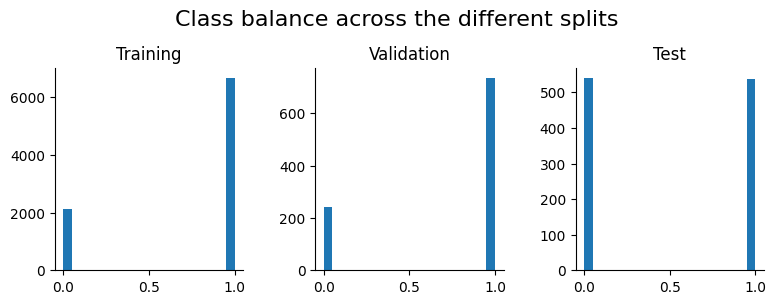

In [28]:
# @title 4. Visualizing the classes
%matplotlib inline

from matplotlib import pyplot as plt
# import matplotlib as mpl
# mpl.rcParams['figure.dpi'] = 300

fig, ax = plt.subplots(1, 3, dpi=100)
fig.suptitle("Class balance across the different splits", fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.9])

fig.set_size_inches(8, 3)
ax[0].hist(train_df['Y'], bins=20)
ax[0].set_title('Training')
ax[1].hist(val_df['Y'], bins=20)
ax[1].set_title('Validation')
ax[2].hist(test_df['Y'], bins=20)
ax[2].set_title('Test')
for i in range(3):
  ax[i].spines[['top', 'right',]].set_visible(False)
plt.show()

The training, validation, and test splits are generated by molecular similarity rather than a purely random split. This gives a more realistic estimate of how well the model generalizes to ChEMBL compounds that are less similar to the ones used for training.


# Training

In [29]:
# @title 1. Define metrics
# @markdown This code defines several metrics for the model. We will not use some of them.

from typing import Any, Callable, List

import numpy as np
import torch
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import (f1_score, matthews_corrcoef,
                             precision_recall_curve, accuracy_score,
                             mean_squared_error, mean_absolute_error,
                             roc_auc_score, auc, confusion_matrix)
from sklearn.metrics.pairwise import cosine_similarity
import transformers as hf


class CustomTrainer(hf.Trainer):
    def save_model(self, output_dir: str = None, _internal_call: bool = False):
        device = self.model.device
        self.model = self.model.cpu()
        super().save_model(output_dir, _internal_call)
        self.model = self.model.to(device)


class Metrics:
    multilabel = False

    def __init__(self):
        self.metrics = {}

    def add_metric(self, name: str, metric: Callable):
        self.metrics[name] = metric

    def get_metrics(self, names: List[str], multilabel: bool = False):
        metrics = Metrics()
        metrics.multilabel = multilabel
        for name in names:
            if name in self.metrics:
                metrics.add_metric(name, self.metrics[name])
            else:
                raise ValueError(f"Metric: {name} not supported.",
                                 " Please use one of the following: ",
                                 f" {list(self.metrics.keys())}")
        return metrics

    def todict(self) -> dict:
        output = {}
        for name, fun in self.metrics.items():
            output[name] = fun
        return output

    def __call__(self, eval_prediction) -> Any:
        output = {}

        preds = eval_prediction.predictions
        refs = eval_prediction.label_ids
        if isinstance(preds, tuple):
            preds = preds[0]

        if len(preds.shape) < 2:
            pass
        elif preds.shape[1] > 1 and not self.multilabel:
            preds = np.argmax(preds, axis=1)

        if preds.dtype != refs.dtype or self.multilabel:
            preds = preds > (1 / preds.shape[1])

        for key, value in self.metrics.items():
          if key == 'cm':
            output2 = value(preds, refs)
            for k2, v2 in output2.items():
              output[k2] = v2
          else:
            output[key] = value(preds, refs)[key]
        return output


def acc(predictions, references, **kwargs):
    return {"acc": accuracy_score(references, predictions)}


def auroc(predictions, references, **kwargs):
    return {"auroc": roc_auc_score(references, predictions)}


def cm_fun(predictions, references, **kwargs):
  cm = confusion_matrix(predictions, references)
  return {'tn': cm[0, 0], 'fp': cm[0, 1], 'tp': cm[1, 1], 'fn': cm[1, 0]}

def tn(predictions, references, **kwargs):
  predictions = predictions < 0.5
  references = references < 0.5
  return {'tn': np.sum(predictions == references)}

def fp(predictions, references, **kwargs):
  predictions = predictions > 0.5
  references = references < 0.5
  return {'fp': np.sum(predictions == references)}

def fn(predictions, references, **kwargs):
  predictions = predictions < 0.5
  references = references > 0.5
  return {'fn': np.sum(predictions == references)}

def precision_at_l5(predictions, references, sequence_lengths, **kwargs):
    prev_pos = 0
    correct = 0
    total = 0
    for idx, label in enumerate(references):
        pred = predictions[prev_pos:prev_pos + label.shape[0] ** 2].toarray().reshape(label.shape[0], label.shape[0], 1)
        label = torch.from_numpy(label)
        prev_pos += label.shape[0] ** 2
        length = sequence_lengths[idx]
        pred = torch.from_numpy(pred).float()
        prob = torch.nn.functional.softmax(pred).view(-1)
        most_likely = prob.topk(length // 5, sorted=False)
        selected = label.view(-1).gather(0, most_likely.indices)
        correct += selected.sum().float()
        total += selected.numel()

    return correct / total


def cosine(predictions, references, **kwargs):
    cosine = list(map(lambda x: cosine_similarity(x[0].reshape(1, -1),
                                                  x[1].reshape(1, -1)).item(),
                                                  predictions))
    cosine, references = np.array(cosine), np.array(references)
    score, _ = spearmanr(references, cosine)
    return {'cos': float(score)}


def manhattan(predictions, references, **kwargs):
    dist = list(map(lambda x: cdist(x[0].reshape(1, -1), x[1].reshape(1, -1),
                                    'cityblock'), predictions))
    norm = list(map(lambda x: (np.linalg.norm(x[0].reshape(1, -1), 1) +
                               np.linalg.norm(x[1].reshape(1, -1), 1)),
                               predictions))

    dist = np.array([1 - (d / n).item() for d, n in zip(dist, norm)])
    # dist = np.array(dist) / (np.linalg.norm(predictions) +
    #                          np.linalg.norm(predictions))
    if isinstance(references, list):
        references = np.array(references)
        # references = references.reshape(-1, 1)
    score, _ = spearmanr(dist, references)
    return {'manhattan': float(score)}


def euclidean(predictions, references, **kwargs):
    dist = list(map(lambda x: cdist(x[0].reshape(1, -1), x[1].reshape(1, -1),
                                    'euclidean'), predictions))
    norm = list(map(lambda x: (np.linalg.norm(x[0].reshape(1, -1), 2) +
                               np.linalg.norm(x[1].reshape(1, -1), 2)),
                               predictions))

    dist = np.array([1 - (d / n).item() for d, n in zip(dist, norm)])
    if isinstance(references, list):
        references = np.array(references)

    score, _ = spearmanr(dist, references)
    return {'euclidean': float(score)}


def f1_max(predictions, references, **kwargs):
    beta = 1.0
    fbeta = 0.0
    for i in range(references.shape[-1]):
        if np.sum(references[:, i]) == 0.0:
            continue
        precision, recall, _ = precision_recall_curve(
            y_true=references[:, i], y_score=predictions[:, i]
        )
        numerator = (1 + beta**2) * (precision * recall)
        denominator = ((beta**2 * precision) + recall)
        a = np.divide(numerator, denominator,
                      out=np.zeros_like(numerator),
                      where=(denominator != 0))
        fbeta += np.nanmax(a / references.shape[1])
    return {"f1_max": float(fbeta)}


def f1_binary(predictions, references, **kwargs):
    score = f1_score(
        references, predictions, average='binary', zero_division=0
    )
    return {"f1": float(score)}


def f1_weighted(predictions, references, **kwargs):
    score = f1_score(references, predictions, average='weighted', zero_division=0, **kwargs)
    return {"f1_weighted": float(score) if score.size == 1 else score}


def mcc(predictions, references, **kwargs):
    score = matthews_corrcoef(
        references, predictions
    )
    return {"mcc": float(score)}


def spcc(predictions, references, **kwargs):
    corr, p_value = spearmanr(references, predictions)
    return {"spcc": float(corr)}


def pcc(predictions, references, **kwargs):
    corr, p_value = pearsonr(references, predictions)
    return {"pcc": float(corr)}


def mse(predictions, references, **kwargs):
    return {'mse': mean_squared_error(references, predictions)}


def mae(predictions, references, **kwargs):
    return {'mae': mean_absolute_error(references, predictions)}


def aupr(predictions, references, **kwargs):
    precision, recall, _ = precision_recall_curve(
        y_true=references, y_score=predictions
    )
    return {'aupr': auc(precision, recall)}


metrics_collection = Metrics()
metrics_collection.add_metric('acc', acc)
metrics_collection.add_metric('auroc', auroc)
metrics_collection.add_metric('f1', f1_binary)
metrics_collection.add_metric('f1_weighted', f1_weighted)
metrics_collection.add_metric('f1_max', f1_max)
metrics_collection.add_metric('mcc', mcc)
metrics_collection.add_metric('spcc', spcc)
metrics_collection.add_metric('pcc', pcc)
metrics_collection.add_metric('euclidean', euclidean)
metrics_collection.add_metric('cosine', cosine)
metrics_collection.add_metric('manhattan', manhattan)
metrics_collection.add_metric('mse', mse)
metrics_collection.add_metric('aupr', aupr)
metrics_collection.add_metric('mae', mae)
metrics_collection.add_metric('cm', cm_fun)


In [30]:
# @title 2. Prepare and configure the language model
# @markdown Now we will download the language model for molecules,
# @markdown [MolFormer-XL](https://huggingface.co/ibm/MoLFormer-XL-both-10pct) or [ChemBERTa-2](https://huggingface.co/DeepChem/ChemBERTa-77M-MTR).
# @markdown We use HuggingFace's `transformers` package, which automates and simplifies many operations.

import copy

import transformers as hf
from datasets import Dataset

model_name = 'ibm/MoLFormer-XL-both-10pct' # Try DeepChem/ChemBERTa-77M-MTR
num_labels = 2
metrics = ['acc', 'mcc', 'f1', 'aupr', 'auroc',
           'cm']

tokenizer = hf.AutoTokenizer.from_pretrained(
  model_name, max_length=250, trust_remote_code=True
  )

model = hf.AutoModelForSequenceClassification.from_pretrained(
  model_name, num_labels=num_labels, trust_remote_code=True
)
hf_args = hf.TrainingArguments(
        output_dir='molformer',
        learning_rate=1e-4,
        label_names=['labels'],
        metric_for_best_model='mcc' if num_labels > 1 else 'spcc',
        per_device_train_batch_size=64,
        per_device_eval_batch_size=64,
        num_train_epochs=50,
        greater_is_better=True,
        eval_accumulation_steps=1,
        load_best_model_at_end=True,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        report_to='tensorboard',
    )
ds = {
    'train': Dataset.from_pandas(train_df),
    'val': Dataset.from_pandas(val_df),
    'test': Dataset.from_pandas(test_df)
}
for split in ds.keys():
    ds[split] = ds[split].map(
        lambda x: tokenizer(x['Drug'], truncation=True, padding='max_length',
                            max_length=210)
    )
    ds[split] = ds[split].rename_column('Y', 'labels')
    ds[split] = ds[split].class_encode_column('labels')
    ds[split].set_format(
        type='pt', columns=['input_ids', 'attention_mask', 'labels']
    )

trainer = CustomTrainer(
    copy.deepcopy(model),
    args=hf_args,
    train_dataset=ds['train'],
    eval_dataset=ds['val'],
    compute_metrics=metrics_collection.get_metrics(metrics),
    callbacks=[hf.EarlyStoppingCallback(5)]
)



Some weights of MolformerForSequenceClassification were not initialized from the model checkpoint at ibm/MoLFormer-XL-both-10pct and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.dense2.bias', 'classifier.dense2.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(















Map: 100%|██████████| 8805/8805 [00:01<00:00, 4757.34 examples/s]

Stringifying the column: 100%|██████████| 8805/8805 [00:00<00:00, 537308.81 examples/s]

Casting to class labels: 100%|██████████| 8805/8805 [00:00<00:00, 407670.24 examples/s]


Map: 100%|██████████| 979/979 [00:00<00:

In [38]:
# @title 3. Training
# @markdown Finally, we will train the model. If you look at the code, this part is simple.

import inspect
import torch

# PyTorch 2.6+ defaults torch.load to weights_only=True, but Transformers
# checkpoints include RNG state with NumPy objects. This local checkpoint was
# generated by this notebook, so resume with trusted-checkpoint loading.
if 'weights_only' in inspect.signature(torch.load).parameters and not getattr(torch.load, '_molformer_resume_patch', False):
    _original_torch_load = torch.load

    def _torch_load_trusted_checkpoint(*args, **kwargs):
        kwargs.setdefault('weights_only', False)
        return _original_torch_load(*args, **kwargs)

    _torch_load_trusted_checkpoint._molformer_resume_patch = True
    torch.load = _torch_load_trusted_checkpoint

values = trainer.train(resume_from_checkpoint='molformer/checkpoint-966')
trainer._load_best_model()


  0%|          | 0/6900 [00:00<?, ?it/s]/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
 14%|█▍        | 1000/6900 [01:36<1:18:12,  1.26it/s]

{'loss': 0.1301, 'grad_norm': 2.534327983856201, 'learning_rate': 8.55072463768116e-05, 'epoch': 7.25}


 16%|█▌        | 1104/6900 [06:32<3:48:41,  2.37s/it]

{'eval_loss': 0.38392701745033264, 'eval_acc': 0.8794688457609806, 'eval_mcc': 0.6797776245959442, 'eval_f1': 0.9195088676671214, 'eval_aupr': 0.19940169634388868, 'eval_auroc': 0.8426540973340488, 'eval_tn': 187, 'eval_fp': 62, 'eval_tp': 674, 'eval_fn': 56, 'eval_runtime': 13.7642, 'eval_samples_per_second': 71.127, 'eval_steps_per_second': 1.162, 'epoch': 8.0}


 16%|█▌        | 1104/6900 [06:34<34:30,  2.80it/s]  

{'train_runtime': 394.4173, 'train_samples_per_second': 1116.204, 'train_steps_per_second': 17.494, 'train_loss': 0.018279078214064888, 'epoch': 8.0}


# Evaluation

In [41]:
# @title 1. Several metrics
# @markdown The final exam for our model: how well it generalizes to held-out ChEMBL compounds
# @markdown from the selected target activity dataset.

# metrics = trainer.evaluate(eval_dataset=ds['test'], metric_key_prefix='test')
# met_df = pd.DataFrame([metrics])
# met_df.head()
trainer._load_from_checkpoint("molformer/checkpoint-966")
metrics = trainer.evaluate(ds["test"], metric_key_prefix="test")
met_df = pd.DataFrame([metrics])
met_df.head()

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 17/17 [00:14<00:00,  1.19it/s]


,test_loss,test_acc,test_mcc,test_f1,test_aupr,test_auroc,test_tn,test_fp,test_tp,test_fn,test_runtime,test_samples_per_second,test_steps_per_second,epoch
0,0.2901,0.90538,0.810943,0.903955,0.432363,0.905338,496,57,480,45,15.2297,70.783,1.116,8.0


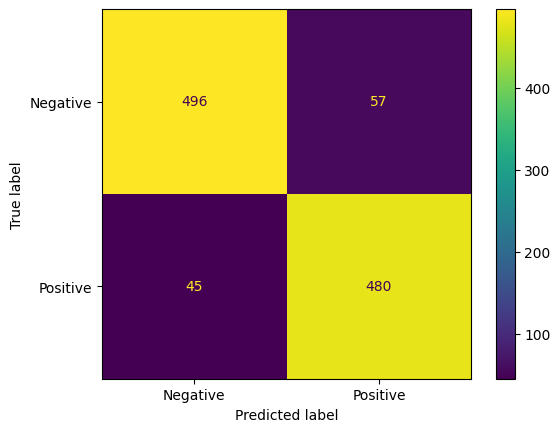

In [42]:
# @title 2. Visualizing the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = np.array([[metrics['test_tn'], metrics['test_fp']],
              [metrics['test_fn'], metrics['test_tp']]])

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Negative', 'Positive'])
disp.plot()

plt.show()